# Tutorial 2: Sweeping the accuracy of a LOM across a parameter space

For users with a wide range of parameter regimes, you may want to compare the model accuracy across a wide range of values.  This tutorial allows you to compare the accuracy of each LOM method for a sweep of values. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skrf as rf

# lcfitter top-level imports
from simpleLOMs import CPWParams, FosterFit, OptimizedFit, AnalyticalFit, analyze_system

# Sub-module imports used in Section 2
from simpleLOMs.elements import coupling_capacitor, shunt_capacitor, lc_resonator
from simpleLOMs.networks.cpw import cpw_resonator_network_2port
from simpleLOMs.networks.lc import lc_resonator_network_2port, lc_resonator_network_with_grounds_2port
from simpleLOMs.analysis import resonance, fwhm_from_trace_db, resonances_from_s
from simpleLOMs.plotting import plot_re_im, plot_lom_vs_data_re_im, plot_all_models
from simpleLOMs.models.optimized_fit import OptimizationConfig
from simpleLOMs import system

print("All imports OK")

All imports OK


In [2]:
cpw_params = CPWParams(
    w=11.7e-6,              # center conductor width (m)
    s=5.1e-6,               # gap spacing (m)
    t=0.0,                  # metal thickness — 0 = ideal thin film
    h=500e-6,               # substrate height (m)
    rho=1e-19,              # resistivity ≈ 0 → superconducting limit
    ep_r=11.45,             # relative permittivity (ultracold silicon)
    has_metal_backside=True,
    tand=0.0,               # lossless substrate
)

print(cpw_params) 

d     = 7.0e-3    # Resonator length (m). This system sets resonance near 8.5 GHz
Z0    = 50.0      # reference impedance in Ohms

Cc1   = 6.0e-14   # coupling capacitor, port 1 (F)
Cc2   = 5.0e-14   # coupling capacitor, port 2 (F)
Ctog1 = 4.0e-14   # shunt-to-ground cap, port 1 side (F)
Ctog2 = 6.0e-14   # shunt-to-ground cap, port 2 side (F)


Lload1 = 2e-09  # load 1 inductance (H)
Cload1 = 6.0e-13  # load 1 capacitance (F)
Lload2 = 4e-09  # load 2 inductance (H)
Cload2 = 6.0e-13  # load 2 capacitance (F)

# We can get the load's bare resonannce from the known LC formula.
f_load1 = 1.0 / (2 * np.pi * np.sqrt(Lload1 * Cload1)) / 1e9
f_load2 = 1.0 / (2 * np.pi * np.sqrt(Lload2 * Cload2)) / 1e9
print(f"Load 1 bare resonance: {f_load1:.4f} GHz")
print(f"Load 2 bare resonance: {f_load2:.4f} GHz")

CPWParams(w=1.17e-05, s=5.1e-06, t=0.0, h=0.0005, rho=1e-19, ep_r=11.45, has_metal_backside=True, tand=0.0)
Load 1 bare resonance: 4.5944 GHz
Load 2 bare resonance: 3.2487 GHz


In [3]:
freq = rf.Frequency(4e9, 12e9, 100_001, unit="Hz")


For this tutorial we set very loose initial parameters but we do not reccomend doing this.

In [4]:
config = OptimizationConfig(
    w0_window_frac=0.005,  
    n_w0=5,              
    n_dense=10,           
    n_widths=1.0,         
    verbose=False,         
)

Sweep grid: Cc1(3) × Cc2(3) = 9 points
Sweeping (9 points)...


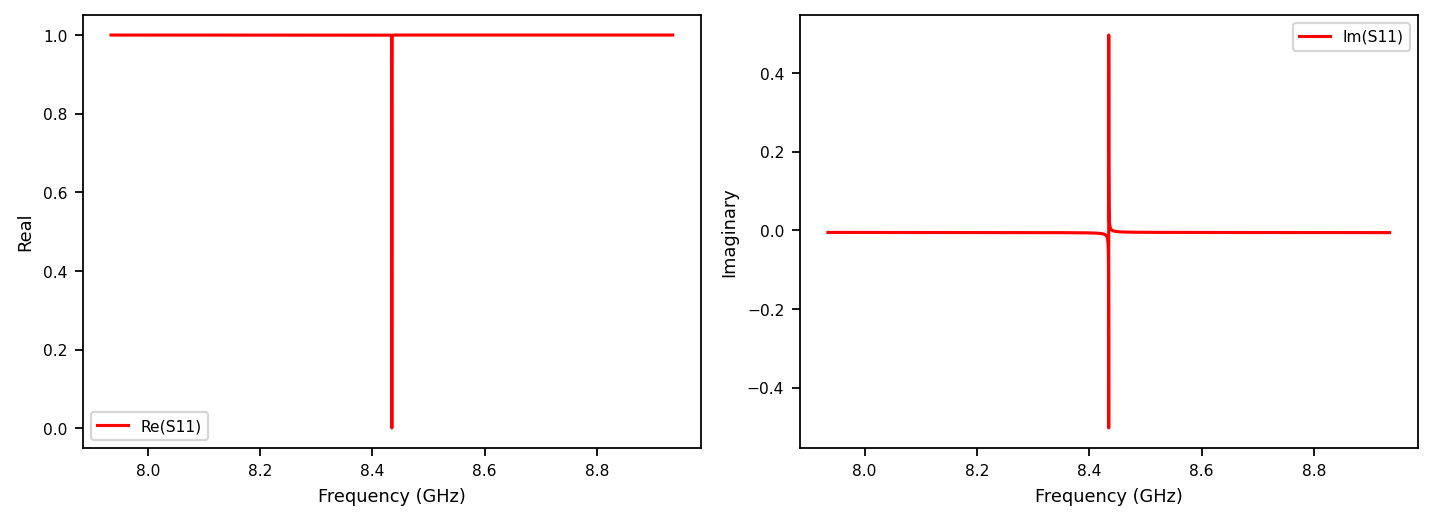

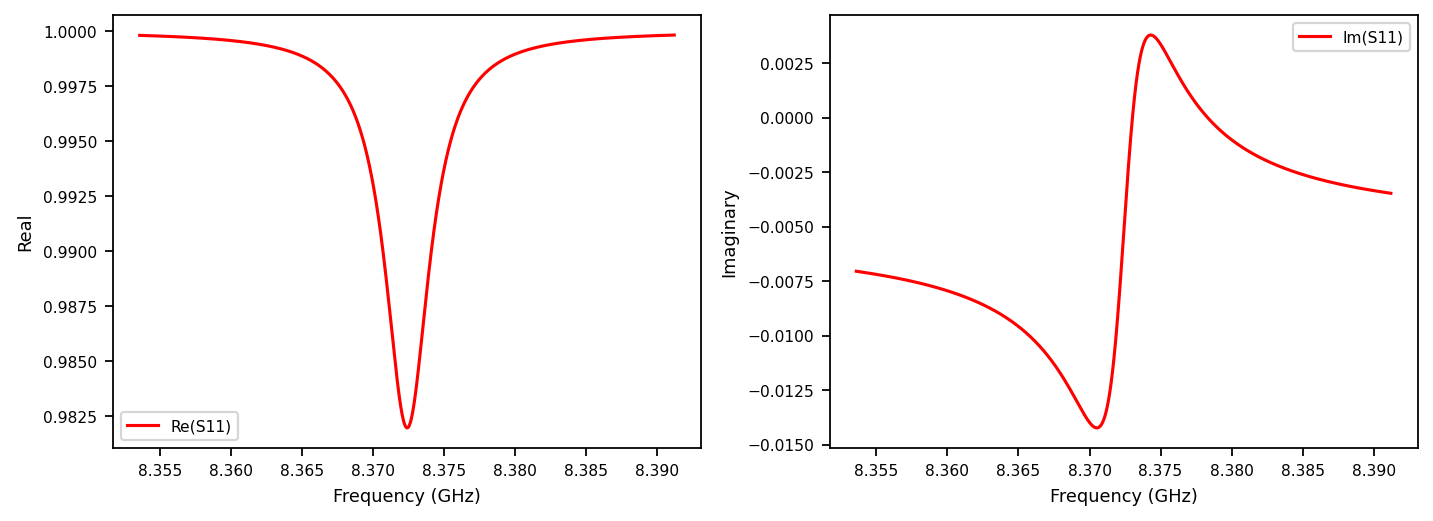

In [ ]:
results_grid = system.run_accuracy_sweep(
    sweep_params={
        "Cc1": np.linspace(1e-15, 20e-15, 3),
        "Cc2": np.linspace(1e-15, 20e-15, 3),
    },
    fixed_params=dict(
        freq=freq, d=7e-3,
        Ctog1=1e-14, Ctog2=1e-14,
        Lload1=5e-10, Cload1=6e-13,
        Lload2=5e-10, Cload2=6e-13,
        cpw_params=cpw_params, Z0=50.0,
        analytical_Z0=45.926,
        opt_config = config
    ),
    save_path="results/cc_sweep.json",
)

In [ ]:
plot_error_heatmap_trio(
    results_grid,
    param1_values=Cc_values,
    param2_values=f_load_values / 1e9,   # already in GHz, scale=1
    param1_label="Cc",
    param2_label="Load frequency",
    metric="shift_max",
    param1_scale=1e15,
    param2_scale=1.0,
    param1_unit="fF",
    param2_unit="GHz",
    title="Max shift error — all models, Cc vs load frequency",
    save_path="figures/trio_shift_max.pdf",
)